### **Part 1 — NLP Techniques & Sentiment Classification**

### Loading and Initial Inspection of Amazon Reviews Data
We'll load the dataset into a pandas DataFrame and display its first few rows to get an initial understanding of the data.

In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Hasan Zaman\Downloads\ITSimplera Solutions Internship\Week 5 (NLP)\amazon_reviews.csv')
display(df.head())

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


### Data Inspection: Structure, Types, and Missing Values
Let's get a summary of the DataFrame to understand its structure, data types, and identify any missing values.

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB
None


Next, let's look at the descriptive statistics of the numerical columns to get a sense of their distribution.

In [3]:
display(df.describe())

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


Finally, we'll check for the total count of missing values in each column to understand data completeness.

In [4]:
display(df.isnull().sum())

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

### Handling Missing Values in `verified_reviews`
We will fill the single missing value in `verified_reviews` with an empty string, as it's a textual feature crucial for NLP tasks.

In [5]:
# Fill any missing 'verified_reviews' with an empty string
df['verified_reviews'] = df['verified_reviews'].fillna('')
print("Missing values in 'verified_reviews' after handling:")
print(df['verified_reviews'].isnull().sum())

Missing values in 'verified_reviews' after handling:
0


### Inspect Review Text, Label Columns & Class Distribution
Let's now examine samples of the `verified_reviews` and `feedback` columns, and then check the distribution of sentiment classes.

In [6]:
print("\nSample of 'verified_reviews' and 'feedback' columns:")
display(df[['verified_reviews', 'feedback', 'rating']].head(10))

print("\nClass distribution of 'feedback' (sentiment) column:")
display(df['feedback'].value_counts())
display(df['feedback'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Sample of 'verified_reviews' and 'feedback' columns:


,verified_reviews,feedback,rating
0,Love my Echo!,1,5
1,Loved it!,1,5
2,"Sometimes while playing a game, you can answer...",1,4
3,I have had a lot of fun with this thing. My 4 ...,1,5
4,Music,1,5
5,I received the echo as a gift. I needed anothe...,1,5
6,"Without having a cellphone, I cannot use many ...",1,3
7,I think this is the 5th one I've purchased. I'...,1,5
8,looks great,1,5
9,Love it! I’ve listened to songs I haven’t hear...,1,5



Class distribution of 'feedback' (sentiment) column:


feedback
1    2893
0     257
Name: count, dtype: int64

feedback
1    91.84%
0     8.16%
Name: proportion, dtype: object

The `feedback` column indicates sentiment (1 for positive, 0 for negative). The class distribution shows a significant imbalance, with a large majority of positive reviews, which is an important consideration for subsequent modeling.

### Clean Raw Text

To prepare the `verified_reviews` for NLP tasks, we need to clean the text data. This involves several preprocessing steps to remove noise and standardize the text:

1.  **Lowercasing**: Convert all text to lowercase to treat words like 'Good' and 'good' as the same.
2.  **Remove Punctuation**: Punctuation marks often don't carry significant meaning for sentiment analysis.
3.  **Remove Numbers**: Numbers are generally irrelevant for sentiment.
4.  **Remove Stop Words**: Eliminate common words (like 'the', 'is', 'a') that do not add much information to the text's meaning.
5.  **Lemmatization**: Reduce words to their base or root form (e.g., 'running', 'ran', 'runs' all become 'run'). Lemmatization is preferred over stemming as it converts words to their meaningful base form.

In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])

    # 3. Remove numbers
    text = ''.join([char for char in text if not char.isdigit()])

    # 4. Remove stop words and 5. Lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Apply the cleaning function to the 'verified_reviews' column
df['cleaned_reviews'] = df['verified_reviews'].apply(clean_text)

print("Sample of original vs. cleaned reviews:")
display(df[['verified_reviews', 'cleaned_reviews', 'feedback']].head())

[nltk_data] Downloading package stopwords to C:\Users\Hasan
[nltk_data]     Zaman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Hasan
[nltk_data]     Zaman\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Sample of original vs. cleaned reviews:


,verified_reviews,cleaned_reviews,feedback
0,Love my Echo!,love echo,1
1,Loved it!,loved,1
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...,1
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaur control l...,1
4,Music,music,1


### Generate Word Clouds for Positive and Negative Reviews

Word clouds are a visual representation of text data, used to display keywords in a text. The size of each word indicates its frequency or importance. We will generate separate word clouds for positive and negative reviews to understand the common terms associated with each sentiment.

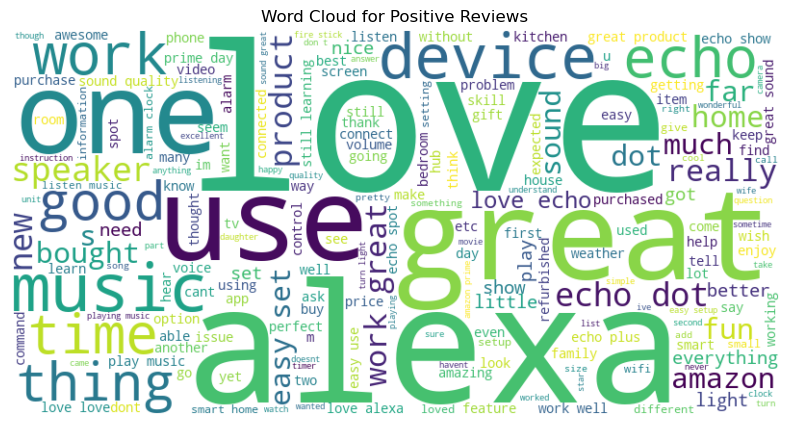

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews based on feedback (sentiment)
positive_reviews = df[df['feedback'] == 1]['cleaned_reviews']
negative_reviews = df[df['feedback'] == 0]['cleaned_reviews']

# Generate Word Cloud for Positive Reviews
positive_text = ' '.join(positive_reviews)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

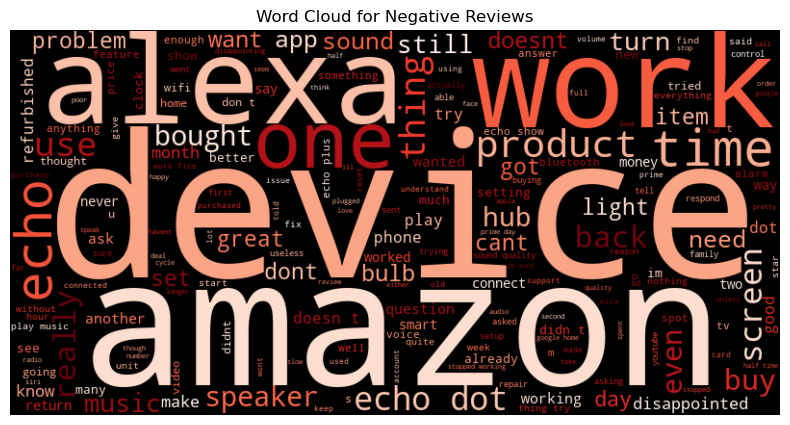

In [11]:
# Generate Word Cloud for Negative Reviews
negative_text = ' '.join(negative_reviews)
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

### Convert Cleaned Text to Numerical Features

To prepare the cleaned text data for machine learning models, we need to convert it into a numerical representation. Text vectorization is the process of converting text into numerical vectors. We will use two common techniques for this:

1.  **TF-IDF (Term Frequency-Inverse Document Frequency)**: This technique reflects how important a word is to a document in a collection or corpus. Words that are common across many documents might have lower TF-IDF scores, while unique words in specific documents will have higher scores. TF-IDF is particularly useful for highlighting words that are significant to a particular review within the entire dataset.
2.  **CountVectorizer**: This method converts a collection of text documents to a matrix of token counts. Each row represents a document, and each column represents a word in the vocabulary, with cell values indicating the frequency of that word in the document. It's a simple yet effective way to represent text numerically.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for practical reasons
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_reviews'])

# Initialize Count Vectorizer
count_vectorizer = CountVectorizer(max_features=5000) # Limiting to 5000 features
X_count = count_vectorizer.fit_transform(df['cleaned_reviews'])

# Prepare the target variable (feedback)
y = df['feedback']

print("Shape of TF-IDF vectorized data:", X_tfidf.shape)
print("Shape of Count vectorized data:", X_count.shape)
print("Shape of target variable:", y.shape)

print("\nFirst 5 TF-IDF features for the first review:")
print(X_tfidf[0].toarray()[0][:5])

print("\nFirst 5 Count features for the first review:")
print(X_count[0].toarray()[0][:5])

Shape of TF-IDF vectorized data: (3150, 3854)
Shape of Count vectorized data: (3150, 3854)
Shape of target variable: (3150,)

First 5 TF-IDF features for the first review:
[0. 0. 0. 0. 0.]

First 5 Count features for the first review:
[0 0 0 0 0]


### Split Data and Train at Least Two Text Classification Models

Before training any models, we need to split our dataset into training and testing sets. This allows us to train the models on one portion of the data and evaluate their performance on unseen data, ensuring that our models generalize well. We will use a standard 80/20 split (80% for training, 20% for testing).

For text classification, common and effective models include:

1.  **Logistic Regression**: A linear model used for binary classification. Despite its simplicity, it often performs well on text data, especially with well-vectorized features.
2.  **Multinomial Naive Bayes**: A probabilistic classifier that is often used for text classification. It works well with discrete features (like word counts or TF-IDF scores) and assumes independence between features.

We will train both models using the TF-IDF vectorized data first, as it often provides better performance due to its ability to downweight common words.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Split the TF-IDF vectorized data into training and testing sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print("TF-IDF Data Split Shapes:")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

TF-IDF Data Split Shapes:
X_train_tfidf shape: (2520, 3854)
X_test_tfidf shape: (630, 3854)
y_train shape: (2520,)
y_test shape: (630,)


### Train Logistic Regression Model (TF-IDF)

In [14]:
from sklearn.linear_model import LogisticRegression

# --- Train Logistic Regression Model (TF-IDF) with Balanced Weights ---
print("\nTraining Logistic Regression Model...")
logistic_model_tfidf = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    solver='liblinear',
    class_weight='balanced'  # Adjusts weights inversely proportional to class frequencies
)
logistic_model_tfidf.fit(X_train_tfidf, y_train)
print("Logistic Regression Model Trained.")


Training Logistic Regression Model...
Logistic Regression Model Trained.


### Train Multinomial Naive Bayes Model (TF-IDF)

In [15]:
from sklearn.naive_bayes import MultinomialNB

# --- Train Multinomial Naive Bayes Model (TF-IDF) ---
print("\nTraining Multinomial Naive Bayes Model...")

# Setting fit_prior=False prevents the 92/8 class imbalance from skewing prior probabilities
naive_bayes_model_tfidf = MultinomialNB(fit_prior=False)
naive_bayes_model_tfidf.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes Model Trained.")


Training Multinomial Naive Bayes Model...
Multinomial Naive Bayes Model Trained.


We will also train the same models using the Count Vectorized data to compare their performance.

In [16]:
# Split the Count vectorized data into training and testing sets
X_train_count, X_test_count, y_train_count, y_test_count = train_test_split(X_count, y, test_size=0.2, random_state=42, stratify=y)

print("Count Data Split Shapes:")
print(f"X_train_count shape: {X_train_count.shape}")
print(f"X_test_count shape: {X_test_count.shape}")
print(f"y_train_count shape: {y_train_count.shape}")
print(f"y_test_count shape: {y_test_count.shape}")

Count Data Split Shapes:
X_train_count shape: (2520, 3854)
X_test_count shape: (630, 3854)
y_train_count shape: (2520,)
y_test_count shape: (630,)


### Train Logistic Regression Model (CountVectorizer)

In [17]:
from sklearn.linear_model import LogisticRegression

# --- Train Logistic Regression Model (CountVectorizer) ---
print("\nTraining Logistic Regression Model (CountVectorizer)...")
logistic_model_count = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    solver='liblinear',
    class_weight='balanced'  # Automatically balances weights for positive vs. negative reviews
)
logistic_model_count.fit(X_train_count, y_train_count)
print("Logistic Regression Model (CountVectorizer) Trained.")


Training Logistic Regression Model (CountVectorizer)...
Logistic Regression Model (CountVectorizer) Trained.


### Train Multinomial Naive Bayes Model (CountVectorizer)

In [18]:
from sklearn.naive_bayes import MultinomialNB

# --- Train Multinomial Naive Bayes Model (CountVectorizer) ---
print("\nTraining Multinomial Naive Bayes Model (CountVectorizer)...")
naive_bayes_model_count = MultinomialNB(
    fit_prior=False  # Treats positive and negative classes with equal weight
)
naive_bayes_model_count.fit(X_train_count, y_train_count)
print("Multinomial Naive Bayes Model (CountVectorizer) Trained.")


Training Multinomial Naive Bayes Model (CountVectorizer)...
Multinomial Naive Bayes Model (CountVectorizer) Trained.


### Evaluate Models with Metrics and Confusion Matrices

After training the models, it's crucial to evaluate their performance on the test sets. We will use several common classification metrics:

*   **Accuracy**: The proportion of correctly classified instances.
*   **Precision**: The proportion of positive identifications that were actually correct.
*   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly.
*   **F1-Score**: The harmonic mean of precision and recall, providing a balance between the two.
*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. We will specifically look at True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).


--- Logistic Regression (TF-IDF) Performance ---
Accuracy: 0.9206
Precision: 0.9401
Recall: 0.9206
F1-Score: 0.9278


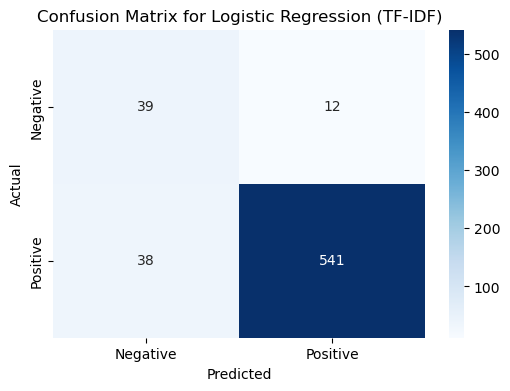


--- Multinomial Naive Bayes (TF-IDF) Performance ---
Accuracy: 0.8968
Precision: 0.8921
Recall: 0.8968
F1-Score: 0.8944


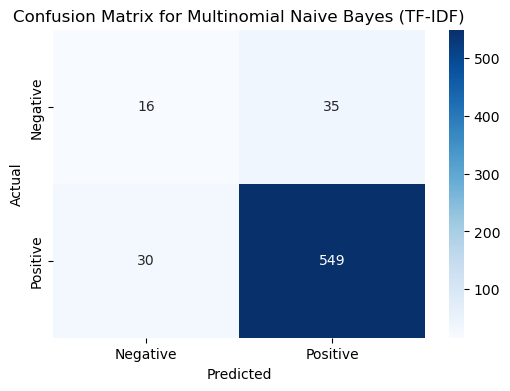


--- Logistic Regression (CountVectorizer) Performance ---
Accuracy: 0.9317
Precision: 0.9389
Recall: 0.9317
F1-Score: 0.9347


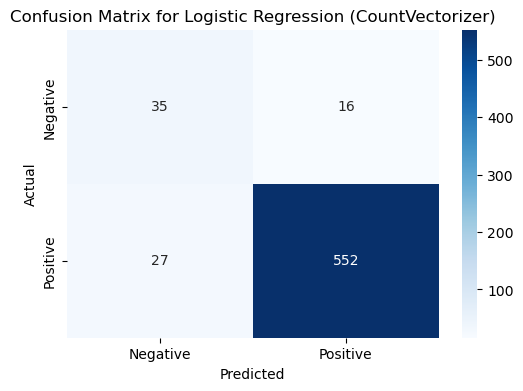


--- Multinomial Naive Bayes (CountVectorizer) Performance ---
Accuracy: 0.9000
Precision: 0.9233
Recall: 0.9000
F1-Score: 0.9093


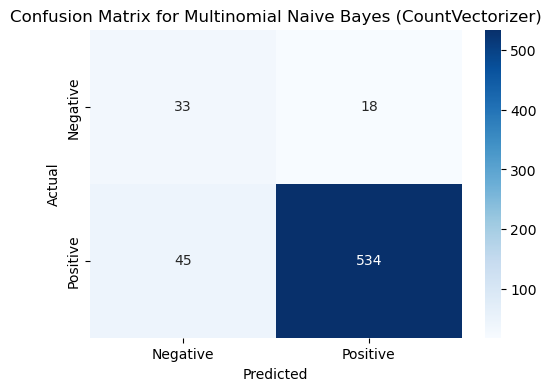

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}") # Use 'weighted' for imbalanced classes
    print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

# Evaluate Logistic Regression (TF-IDF)
evaluate_model(logistic_model_tfidf, X_test_tfidf, y_test, "Logistic Regression (TF-IDF)")

# Evaluate Multinomial Naive Bayes (TF-IDF)
evaluate_model(naive_bayes_model_tfidf, X_test_tfidf, y_test, "Multinomial Naive Bayes (TF-IDF)")

# Evaluate Logistic Regression (CountVectorizer)
evaluate_model(logistic_model_count, X_test_count, y_test_count, "Logistic Regression (CountVectorizer)")

# Evaluate Multinomial Naive Bayes (CountVectorizer)
evaluate_model(naive_bayes_model_count, X_test_count, y_test_count, "Multinomial Naive Bayes (CountVectorizer)")

### Comparative Analysis of Model Performance

To better understand which model performs best, we will gather all evaluation metrics (Accuracy, Precision, Recall, F1-Score) for each model and present them in a comparative chart.

,Accuracy,Precision,Recall,F1-Score
Logistic Regression (TF-IDF),0.920635,0.940106,0.920635,0.927784
Multinomial Naive Bayes (TF-IDF),0.896825,0.892125,0.896825,0.894388
Logistic Regression (CountVectorizer),0.931746,0.938858,0.931746,0.934741
Multinomial Naive Bayes (CountVectorizer),0.900000,0.923328,0.900000,0.909271


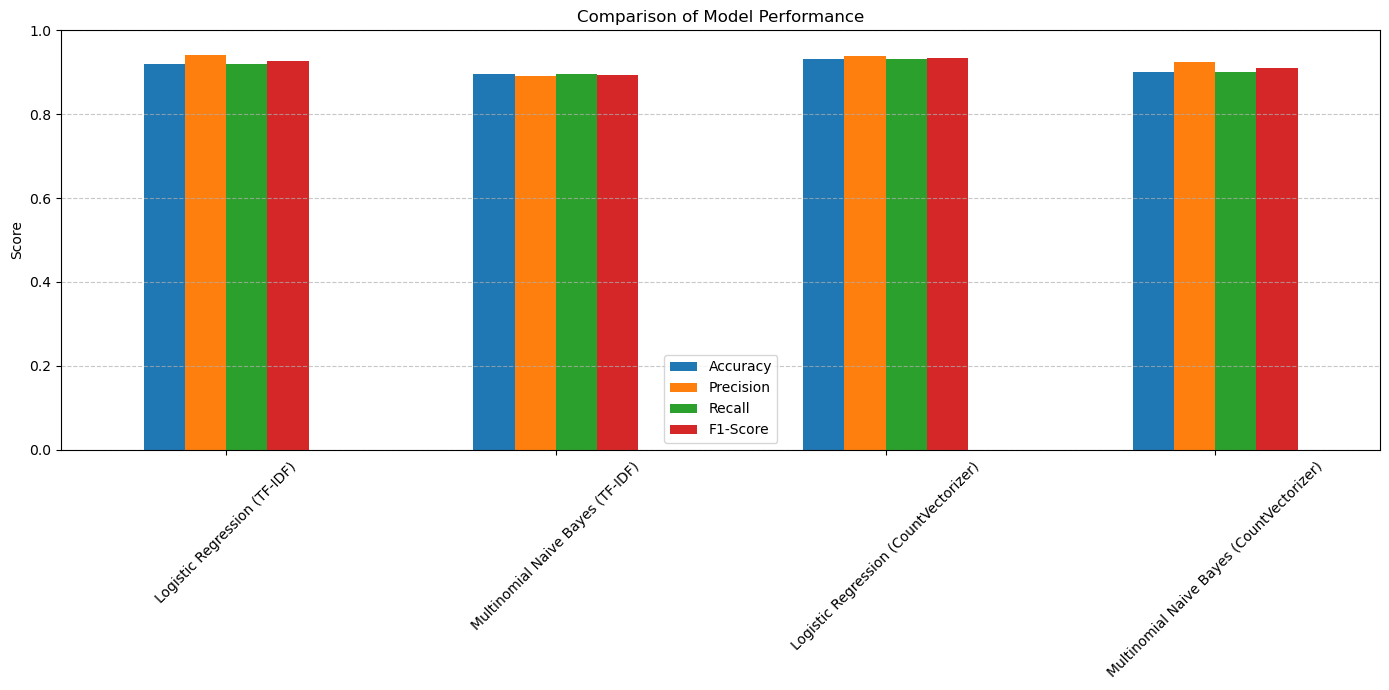

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to get metrics for a model
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

# Collect metrics for all models
metrics = {}
metrics['Logistic Regression (TF-IDF)'] = get_metrics(logistic_model_tfidf, X_test_tfidf, y_test)
metrics['Multinomial Naive Bayes (TF-IDF)'] = get_metrics(naive_bayes_model_tfidf, X_test_tfidf, y_test)
metrics['Logistic Regression (CountVectorizer)'] = get_metrics(logistic_model_count, X_test_count, y_test_count)
metrics['Multinomial Naive Bayes (CountVectorizer)'] = get_metrics(naive_bayes_model_count, X_test_count, y_test_count)

# Create a DataFrame for easy plotting
metrics_df = pd.DataFrame(metrics, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
display(metrics_df)

# Plotting the comparison
metrics_df.plot(kind='bar', figsize=(14, 7), rot=45)
plt.title('Comparison of Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Saving the Best Performing Model and Vectorizer

Based on the evaluation, the **Logistic Regression model with CountVectorizer features** demonstrated the best performance across multiple metrics. For deployment, we will save this model and its corresponding `CountVectorizer` to disk.

In [21]:
import joblib
import os

# Define paths for saving
model_save_path = 'logistic_regression_count_model.joblib'
vectorizer_save_path = 'count_vectorizer.joblib'

# Save the best model (Logistic Regression with CountVectorizer)
joblib.dump(logistic_model_count, model_save_path)
print(f"Best model saved to {model_save_path}")

# Save the corresponding vectorizer (CountVectorizer)
joblib.dump(count_vectorizer, vectorizer_save_path)
print(f"CountVectorizer saved to {vectorizer_save_path}")

print("\nVerification of saved files:")
print(f"Model file exists: {os.path.exists(model_save_path)}")
print(f"Vectorizer file exists: {os.path.exists(vectorizer_save_path)}")

Best model saved to logistic_regression_count_model.joblib


CountVectorizer saved to count_vectorizer.joblib

Verification of saved files:
Model file exists: True
Vectorizer file exists: True


## Part 2 — Streamlit Dashboard

Now that we have trained and saved our best sentiment analysis model, we will build a Streamlit dashboard to deploy it. This dashboard will have three main pages:

1.  **Home**: An introductory page for our sentiment analysis app.
2.  **Data Overview**: A page to display key insights and statistics from our dataset.
3.  **Sentiment Predictor**: The core functionality, where users can input text reviews and get real-time sentiment predictions.

We will ensure the app loads the saved model and vectorizer, and applies the same text cleaning steps to new input reviews before making predictions.

In [ ]:
%%writefile streamlit_app.py

import streamlit as st
import joblib
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# --- 1. Streamlit Page Configuration ---
st.set_page_config(page_title="Amazon Review Sentiment Analysis", layout="centered")

# --- 2. Download NLTK Resources (Cached) ---
@st.cache_resource
def download_nltk_data():
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)

download_nltk_data()

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    text = ''.join([char for char in text if not char.isdigit()])
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# --- 3. Load Model and Vectorizer ---
model_path = 'logistic_regression_count_model.joblib'
vectorizer_path = 'count_vectorizer.joblib'

try:
    model = joblib.load(model_path)
    vectorizer = joblib.load(vectorizer_path)
except FileNotFoundError:
    st.error(f"Error: Model or vectorizer file not found in current directory. Please check '{model_path}' and '{vectorizer_path}'.")
    st.stop()

# --- 4. Load & Cache Dataset for Performance ---
@st.cache_data
def load_data():
    try:
        # Use relative path assuming amazon_reviews.csv is in the project root
        data = pd.read_csv('amazon_reviews.csv')
        data['verified_reviews'] = data['verified_reviews'].fillna('')
        data['cleaned_reviews'] = data['verified_reviews'].apply(clean_text)
        return data
    except Exception:
        return None

df = load_data()

# --- Sidebar Navigation ---
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Home", "Data Overview", "Sentiment Predictor"])

# --- Page: Home ---
if page == "Home":
    st.title("Welcome to the Amazon Review Sentiment Analyzer")
    st.write("This application allows us to analyze the sentiment of Amazon product reviews. "
             "We can explore the dataset, and predict the sentiment (positive or negative) of new review texts.")
    st.image("https://i.imgur.com/Qj0Y5k1.png", use_container_width=True, caption="Sentiment Analysis")
    st.markdown("### About This Project")
    st.write("This project was developed as part of a machine learning assignment, "
             "focusing on Natural Language Processing (NLP) techniques to classify "
             "customer feedback. We used various text vectorization methods and "
             "classification models to identify the most effective approach.")

# --- Page: Data Overview ---
elif page == "Data Overview":
    st.title("Dataset Overview")
    st.write("Here we provide a quick overview of the Amazon Reviews dataset that we used for training our models.")

    if df is not None:
        st.markdown("### Raw Data Sample")
        st.dataframe(df[['verified_reviews', 'feedback', 'rating']].head())

        st.markdown("### Dataset Information")
        st.write(f"Total reviews: {len(df)}")
        st.write(f"Columns: {df.columns.tolist()}")

        st.markdown("### Sentiment Distribution")
        feedback_counts = df['feedback'].value_counts().rename(index={1: 'Positive', 0: 'Negative'})
        st.bar_chart(feedback_counts)
        st.write("The distribution of feedback (sentiment):")
        st.dataframe(feedback_counts.to_frame())

        st.markdown("### Rating Distribution")
        rating_counts = df['rating'].value_counts().sort_index()
        st.bar_chart(rating_counts)
        st.write("The distribution of ratings:")
        st.dataframe(rating_counts.to_frame())
    else:
        st.info("Data overview is unavailable because 'amazon_reviews.csv' could not be loaded from the project directory.")

# --- Page: Sentiment Predictor ---
elif page == "Sentiment Predictor":
    st.title("Predict Review Sentiment")
    st.write("Enter an Amazon product review below to predict its sentiment (Positive or Negative).")

    user_input = st.text_area("Enter your review here:", "This product is absolutely amazing! I love it.")

    if st.button("Predict Sentiment"):
        if user_input:
            cleaned_input = clean_text(user_input)

            if cleaned_input:
                vectorized_input = vectorizer.transform([cleaned_input])

                prediction = model.predict(vectorized_input)
                prediction_proba = model.predict_proba(vectorized_input)

                sentiment = "Positive" if prediction[0] == 1 else "Negative"
                confidence = prediction_proba[0][prediction[0]] * 100

                st.write("\n--- Prediction ---")
                color = "green" if sentiment == "Positive" else "red"
                st.markdown(f"**Predicted Sentiment:** <span style='color: {color}; font-size: 20px;'>{sentiment}</span>", unsafe_allow_html=True)
                st.write(f"**Confidence:** {confidence:.2f}%")

                st.markdown("\n### Original vs. Cleaned Input")
                st.write(f"**Original Review:** {user_input}")
                st.write(f"**Cleaned Review:** {cleaned_input}")
            else:
                st.warning("The input review resulted in empty text after cleaning. Please try a different review.")
        else:
            st.warning("Please enter a review to predict its sentiment.")

### How to Run the Streamlit App

To run the Streamlit application from within Google Colab, we need to install Streamlit and then execute the generated Python file using the `streamlit run` command.

1.  **Install Streamlit**: If you haven't already, run `pip install streamlit` in a code cell.
2.  **Run the App**: Execute the following command in a new code cell (or a shell cell by prefixing with `!`):
    ```bash
    !streamlit run streamlit_app.py &>/dev/null&
    ```
    *   The `&>/dev/null&` part sends the output to `/dev/null` (discards it) and runs the process in the background, which is common practice in Colab to avoid blocking the cell output.
3.  **Access the App**: Streamlit will typically create a public URL (ngrok or similar) that you can click to access your app in a new browser tab. Look for a message like `External URL: http://<some-ngrok-url>` in the output of the cell where you run the command. You might need to refresh the page or wait a few seconds for the link to appear.
4.  **Stop the App**: To stop the running Streamlit app, you might need to find its process ID (PID) and kill it. Alternatively, restarting the Colab runtime will also stop it.

Let's install Streamlit and then run the application!

In [24]:
!streamlit run streamlit_app.py